главный target для анализа: Units_Sold

вторичный бизнес-показатель: Revenue_EUR

pandas      -> таблицы и анализ данных
numpy       -> числа, массивы, математика
matplotlib  -> обычные графики
seaborn     -> красивые статистические графики
plotly      -> интерактивные графики
scipy.stats -> статистические тесты
sklearn     -> подготовка данных и машинное обучение

In [115]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction import FeatureHasher

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("bmw_global_sales_2018_2025.csv") #read_csv — функция внутри pandas
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


In [116]:
df.tail()


,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
3067,2025,12,RestOfWorld,X5,9281,68198,632945638,0.201,5.89,2.37,1.41
3068,2025,12,RestOfWorld,X7,12785,91839,1174161615,0.203,5.89,2.37,1.41
3069,2025,12,RestOfWorld,i4,4906,63437,311221922,0.180,5.89,2.37,1.41
3070,2025,12,RestOfWorld,iX,7871,73867,581407157,0.196,5.89,2.37,1.41
3071,2025,12,RestOfWorld,MINI,6732,41811,281471652,0.167,5.89,2.37,1.41


In [117]:
df.shape


(3072, 11)

In [118]:
list(df.columns)

['Year',
 'Month',
 'Region',
 'Model',
 'Units_Sold',
 'Avg_Price_EUR',
 'Revenue_EUR',
 'BEV_Share',
 'Premium_Share',
 'GDP_Growth',
 'Fuel_Price_Index']

In [119]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   str    
 3   Model             3072 non-null   str    
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), str(2)
memory usage: 264.1 KB


In [120]:
df.describe()

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3072.000000,3072.000000,3072.000000,3072.000000,3.072000e+03,3072.000000,3072.000000,3072.000000,3072.000000
mean,2021.500000,6.500000,7980.288086,63854.561523,5.113995e+08,0.107572,14.660234,3.057526,1.176224
std,2.291661,3.452615,3174.917444,14655.891299,2.431185e+08,0.058099,5.334604,1.018103,0.118123
min,2018.000000,1.000000,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
25%,2019.750000,3.750000,5225.500000,54500.250000,3.125504e+08,0.057000,12.275000,2.370000,1.080000
50%,2021.500000,6.500000,7985.500000,63493.000000,4.808690e+08,0.108000,16.260000,3.060000,1.180000
75%,2023.250000,9.250000,10528.250000,71489.500000,6.709141e+08,0.157250,18.932500,3.852500,1.270000
max,2025.000000,12.000000,15914.000000,93994.000000,1.433482e+09,0.223000,20.970000,5.820000,1.410000


Результат df.describe() показывает основные статистические характеристики числовых признаков.
Показатель count отражает число непустых наблюдений, mean — среднее значение признака, std — степень разброса относительно среднего, min и max — минимальное и максимальное значения.(в среднем значения обычно гуляют вокруг mean примерно на эту величину.)
Перцентили 25%, 50% и 75% показывают, как распределены данные: 50% соответствует медиане, а 25% и 75% помогают понять, в каком диапазоне находится основная часть наблюдений.
Сравнение среднего и медианы позволяет сделать предварительный вывод о симметричности распределения и наличии возможных выбросов.

In [121]:
df.describe(include=["object", "str"])

,Region,Model
count,3072,3072
unique,4,8
top,Europe,3 Series
freq,768,384


In [122]:
df.duplicated().sum()#колво дубликатов в дф

np.int64(0)

In [123]:
df.isnull().sum()


Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

In [124]:
df.dtypes

Year                  int64
Month                 int64
Region                  str
Model                   str
Units_Sold            int64
Avg_Price_EUR         int64
Revenue_EUR           int64
BEV_Share           float64
Premium_Share       float64
GDP_Growth          float64
Fuel_Price_Index    float64
dtype: object

In [125]:
checks = {
    "Month range valid": df["Month"].between(1, 12).all(),
    "Year range valid": df["Year"].between(2018, 2025).all(),
    "Units_Sold positive": (df["Units_Sold"] > 0).all(),
    "Avg_Price_EUR positive": (df["Avg_Price_EUR"] > 0).all(),
    "Revenue_EUR positive": (df["Revenue_EUR"] > 0).all(),
    "Fuel_Price_Index positive": (df["Fuel_Price_Index"] > 0).all(),
}# словарь

checks_df = pd.DataFrame({# pd.DataFrame - команда / конструктор, который создаёт таблицу pandas.
    "Check": checks.keys(),# поэтому и keys
    "Result": [bool(v) for v in checks.values()]
})

checks_df

,Check,Result
0,Month range valid,True
1,Year range valid,True
2,Units_Sold positive,True
3,Avg_Price_EUR positive,True
4,Revenue_EUR positive,True
5,Fuel_Price_Index positive,True


In [126]:
df[["BEV_Share", "Premium_Share"]].agg(["min", "max", "mean"])#.agg() — это aggregate, то есть “свернуть данные в итоговые показатели”.

,BEV_Share,Premium_Share
min,-0.015000,5.090000
max,0.223000,20.970000
mean,0.107572,14.660234


In [127]:
(df["Units_Sold"] * df["Avg_Price_EUR"] - df["Revenue_EUR"]).abs().sum()

np.int64(0)

Выручка в датасете не является независимым наблюдением, а строго вычисляется из количества проданных единиц и средней цены. Это важно учитывать в EDA и дальнейшем моделировании, чтобы избежать утечки информации и мультиколлинеарности.

In [128]:
group_counts = df.groupby(["Year", "Month", "Region", "Model"]).size()
group_counts.value_counts()

1    3072
Name: count, dtype: int64

Каждая комбинация год–месяц–регион–модель встречается ровно один раз, значит структура датасета согласована.

В исходном датасете пропуски отсутствуют. Ниже показаны универсальные стратегии обработки пропусков, которые были бы применены при их наличии.

In [129]:
df_drop = df.dropna()

In [130]:
df_fill = df.copy()

num_cols = df_fill.select_dtypes(include=np.number).columns
cat_cols = df_fill.select_dtypes(include=["str", "category"]).columns

for col in num_cols:
    if abs(df_fill[col].skew()) < 1:
        df_fill[col] = df_fill[col].fillna(df_fill[col].mean())
    else:
        df_fill[col] = df_fill[col].fillna(df_fill[col].median())

Данный блок кода демонстрирует стратегию заполнения пропусков в числовых признаках. Для этого создаётся копия исходного датафрейма, выделяются числовые и категориальные столбцы, после чего для числовых признаков выбирается способ заполнения в зависимости от асимметрии распределения: средним значением для более симметричных данных и медианой для асимметричных. В текущем датасете пропуски отсутствуют, поэтому фактических изменений после выполнения этого блока не произошло.

In [131]:
for col in cat_cols:
    mode_value = df_fill[col].mode()[0]
    df_fill[col] = df_fill[col].fillna(mode_value)
    print(col, mode_value)

Region China
Model 3 Series


Для категориальных признаков наиболее естественным способом заполнения является мода, потому что она сохраняет допустимые значения категории и не создаёт искусственных новых уровней.

In [132]:
# Исправление/ограничение доли электромобилей
df["BEV_Share"] = df["BEV_Share"].clip(lower=0, upper=1)

# Если хочешь привести Premium_Share к доле:
df["Premium_Share_ratio"] = df["Premium_Share"] / 100

Отрицательные значения в BEV_Share были интерпретированы как ошибки измерения и ограничены диапазоном [0, 1].

In [133]:
num_cols = df.select_dtypes(include=np.number).columns

stats_table = pd.DataFrame({
    "min": df[num_cols].min(),
    "max": df[num_cols].max(),
    "mean": df[num_cols].mean(),
    "median": df[num_cols].median(),
    "mode": df[num_cols].mode().iloc[0]
})

stats_table

,min,max,mean,median,mode
Year,2.018000e+03,2.025000e+03,2.021500e+03,2.021500e+03,2.018000e+03
Month,1.000000e+00,1.200000e+01,6.500000e+00,6.500000e+00,1.000000e+00
Units_Sold,2.379000e+03,1.591400e+04,7.980288e+03,7.985500e+03,5.827000e+03
Avg_Price_EUR,4.001100e+04,9.399400e+04,6.385456e+04,6.349300e+04,4.293300e+04
Revenue_EUR,1.045314e+08,1.433482e+09,5.113995e+08,4.808690e+08,1.045314e+08
BEV_Share,-0.000000e+00,2.230000e-01,1.075843e-01,1.080000e-01,1.190000e-01
Premium_Share,5.090000e+00,2.097000e+01,1.466023e+01,1.626000e+01,6.870000e+00
GDP_Growth,1.000000e-01,5.820000e+00,3.057526e+00,3.060000e+00,2.370000e+00
Fuel_Price_Index,9.200000e-01,1.410000e+00,1.176224e+00,1.180000e+00,1.180000e+00
Premium_Share_ratio,5.090000e-02,2.097000e-01,1.466023e-01,1.626000e-01,6.870000e-02


feature engineering

In [134]:
df["Date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))

In [135]:
df["Quarter"] = df["Date"].dt.quarter

In [136]:
df["Is_EV_Model"] = df["Model"].isin(["i4", "iX"]).astype(int)

In [137]:
df["Is_SUV"] = df["Model"].astype(str).str.startswith("X").astype(int)

In [138]:
model_counts = df["Model"].value_counts()
rare_models = model_counts[model_counts < 50].index

df["Model_grouped"] = df["Model"].replace(rare_models, "Other")

encoding категориальных признаков

In [139]:
df_ohe = pd.get_dummies(df, columns=["Region", "Model"], drop_first=True)
df_ohe.head()

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Premium_Share_ratio,Date,Quarter,Is_EV_Model,Is_SUV,Model_grouped,Region_Europe,Region_RestOfWorld,Region_USA,Model_5 Series,Model_MINI,Model_X3,Model_X5,Model_X7,Model_i4,Model_iX
0,2018,1,7822,47482,371404204,0.011,19.12,3.5,1.0,0.1912,2018-01-01,1,0,0,3 Series,True,False,False,False,False,False,False,False,False,False
1,2018,1,10280,61685,634121800,0.019,19.12,3.5,1.0,0.1912,2018-01-01,1,0,0,5 Series,True,False,False,True,False,False,False,False,False,False
2,2018,1,3105,58433,181434465,0.022,19.12,3.5,1.0,0.1912,2018-01-01,1,0,1,X3,True,False,False,False,False,True,False,False,False,False
3,2018,1,7420,67955,504226100,0.021,19.12,3.5,1.0,0.1912,2018-01-01,1,0,1,X5,True,False,False,False,False,False,True,False,False,False
4,2018,1,8474,92300,782150200,0.035,19.12,3.5,1.0,0.1912,2018-01-01,1,0,1,X7,True,False,False,False,False,False,False,True,False,False


In [140]:
df_le = df.copy()
le = LabelEncoder()
df_le["Region_LE"] = le.fit_transform(df_le["Region"].astype(str))
df_le["Model_LE"] = le.fit_transform(df_le["Model"].astype(str))

df_le[["Region", "Region_LE", "Model", "Model_LE"]].head()

,Region,Region_LE,Model,Model_LE
0,Europe,1,3 Series,0
1,Europe,1,5 Series,1
2,Europe,1,X3,3
3,Europe,1,X5,4
4,Europe,1,X7,5


Label Encoding для номинальных категорий может вносить ложный порядок между категориями, поэтому для моделей и регионов в данной задаче предпочтительнее One-Hot Encoding.

Target Encoding может быть полезен в задачах прогнозирования Units_Sold, но его корректно применять только внутри кросс-валидации, чтобы избежать утечки таргета.

Feature Hashing обычно полезен при высококардинальных признаках. В данном датасете число категорий мало, поэтому практической необходимости в нём нет.

In [141]:
from sklearn.feature_extraction import FeatureHasher

hasher = FeatureHasher(n_features=4, input_type="string")
samples = [[x] for x in df["Model"].astype(str)]
hashed = hasher.transform(samples)

hashed_df = pd.DataFrame(
    hashed.toarray(),
    columns=[f"hash_{i}" for i in range(4)]
)

hashed_df.head()

,hash_0,hash_1,hash_2,hash_3
0,0.0,0.0,-1.0,0.0
1,0.0,0.0,0.0,-1.0
2,0.0,1.0,0.0,0.0
3,0.0,-1.0,0.0,0.0
4,0.0,0.0,-1.0,0.0


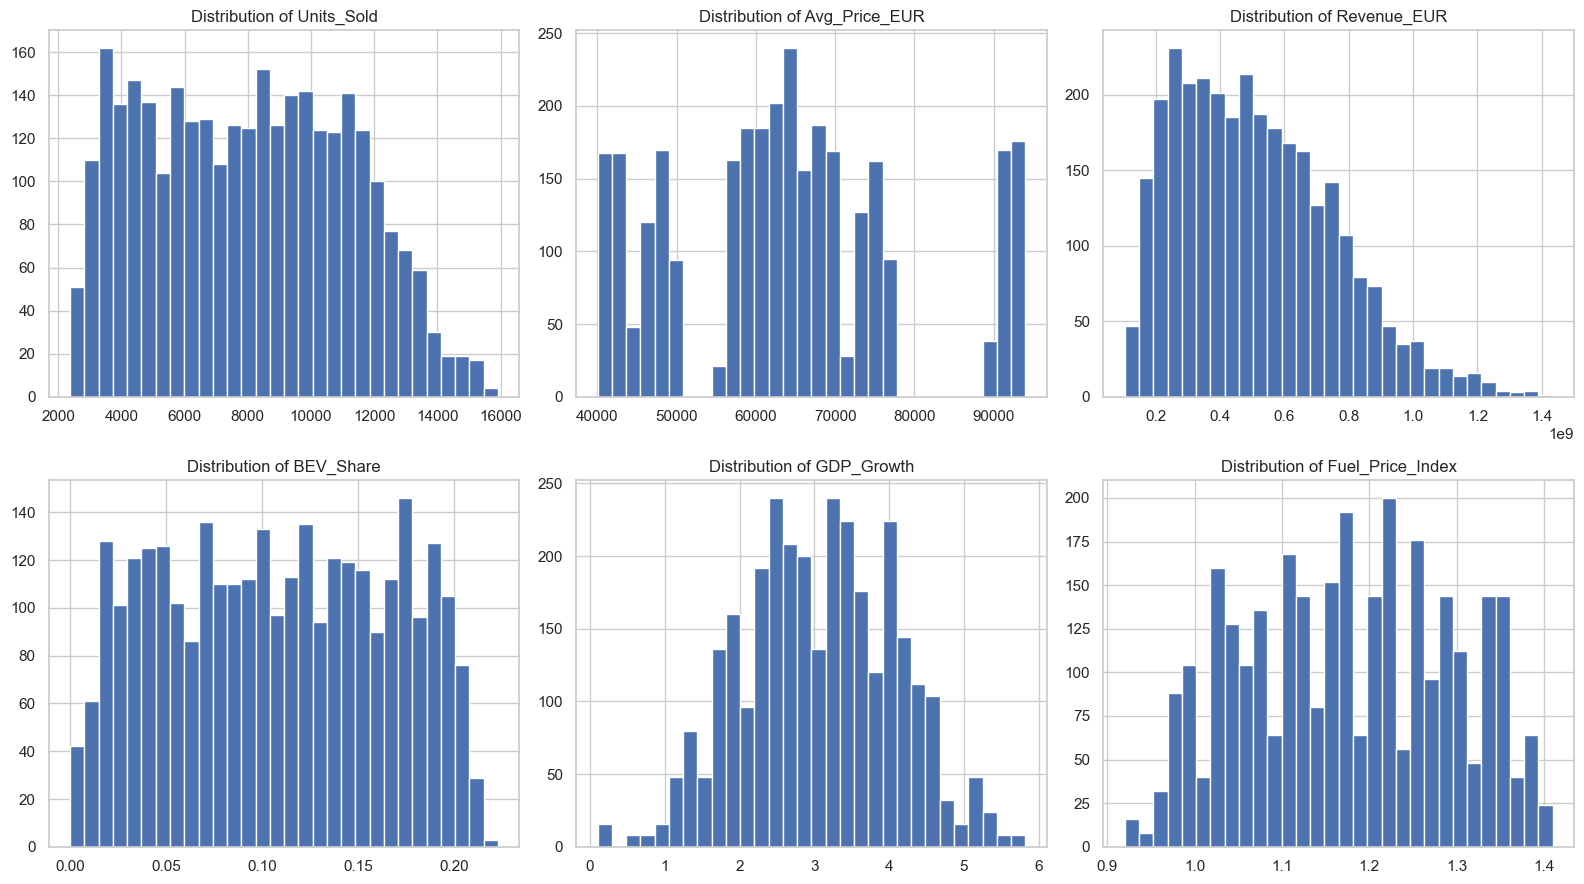

In [142]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cols = ["Units_Sold", "Avg_Price_EUR", "Revenue_EUR", "BEV_Share", "GDP_Growth", "Fuel_Price_Index"]

for ax, col in zip(axes.flatten(), cols):
    ax.hist(df[col], bins=30)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

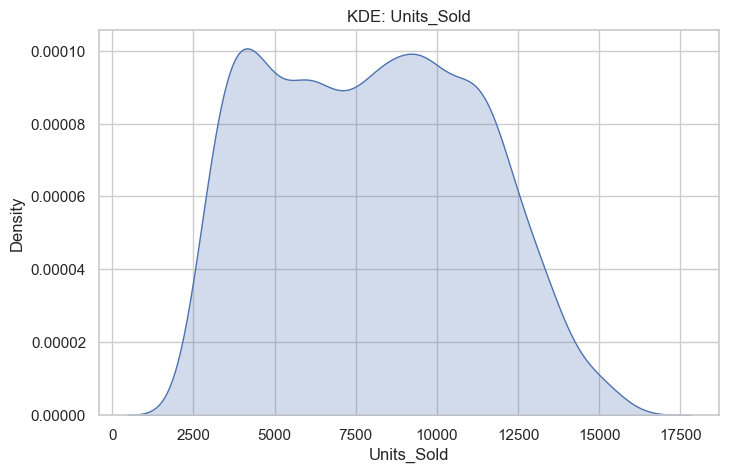

In [143]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df["Units_Sold"], fill=True)
plt.title("KDE: Units_Sold")
plt.show()

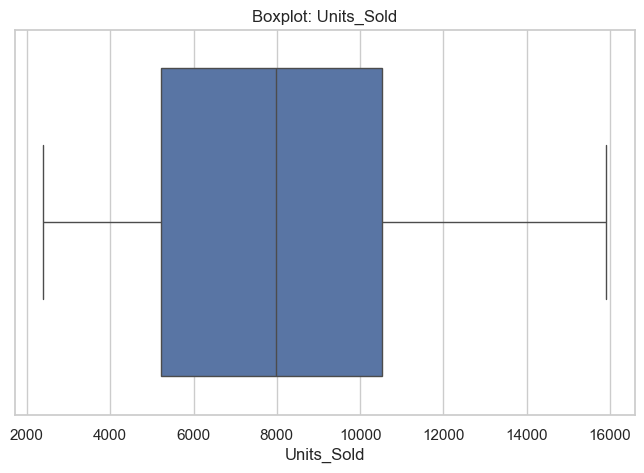

In [144]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Units_Sold"])
plt.title("Boxplot: Units_Sold")
plt.show()

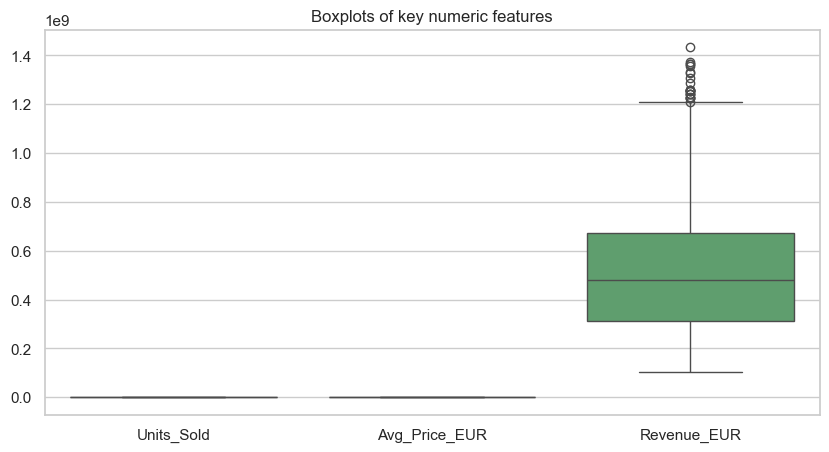

In [145]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[["Units_Sold", "Avg_Price_EUR", "Revenue_EUR"]])
plt.title("Boxplots of key numeric features")
plt.show()

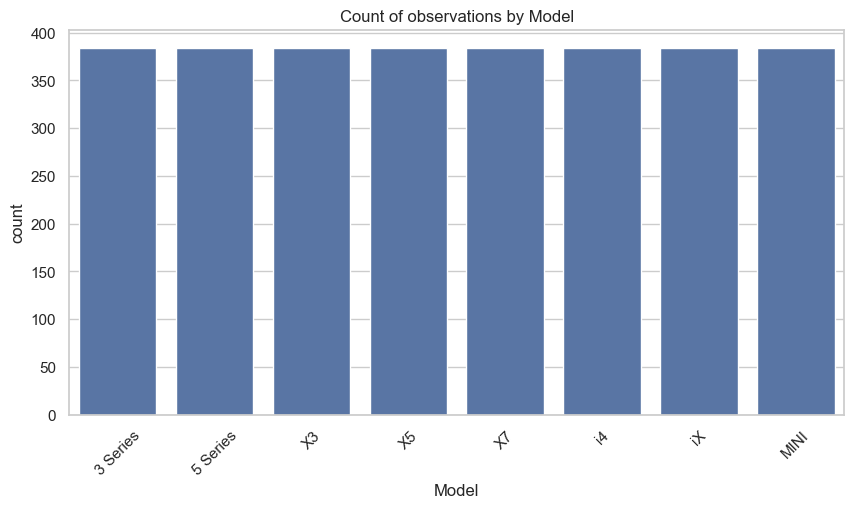

In [146]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Model", order=df["Model"].value_counts().index)
plt.title("Count of observations by Model")
plt.xticks(rotation=45)
plt.show()

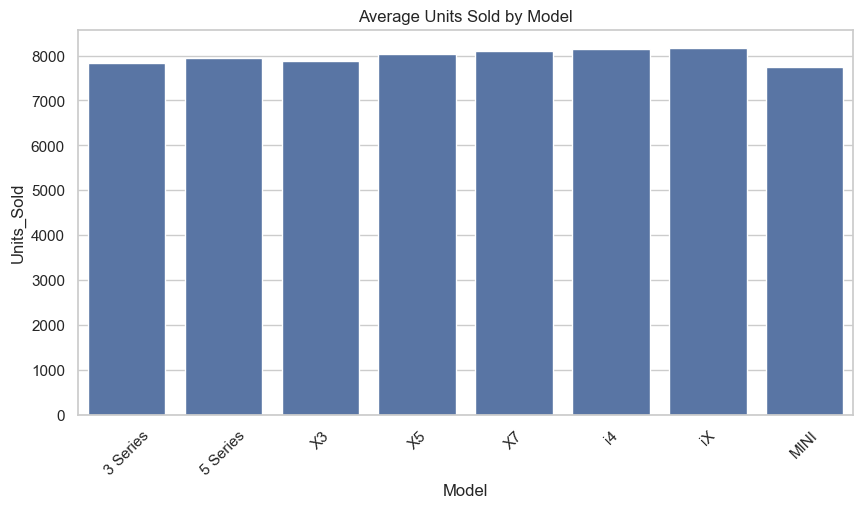

In [147]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Model", y="Units_Sold", estimator=np.mean, errorbar=None)
plt.title("Average Units Sold by Model")
plt.xticks(rotation=45)
plt.show()

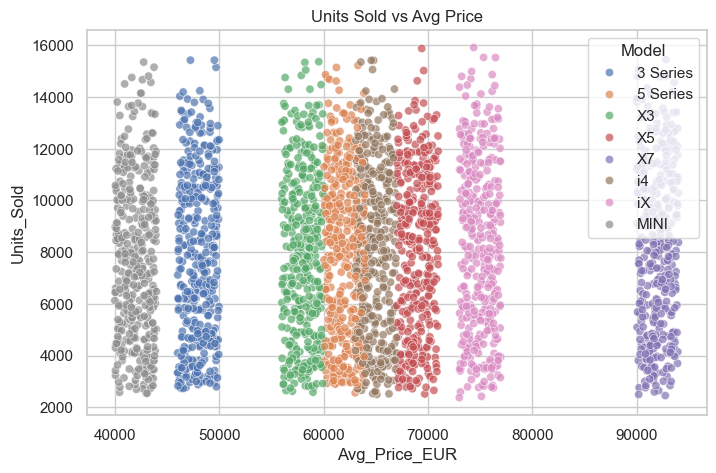

In [148]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Avg_Price_EUR", y="Units_Sold", hue="Model", alpha=0.7)
plt.title("Units Sold vs Avg Price")
plt.show()

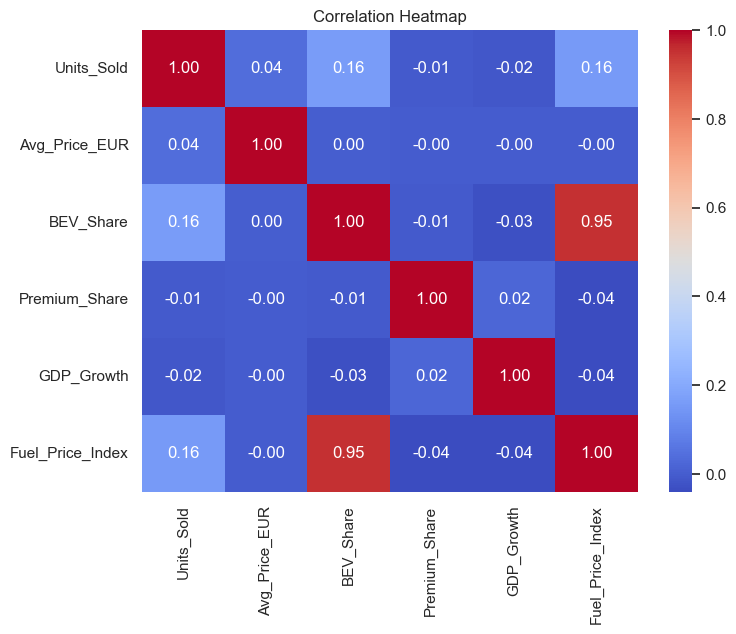

In [149]:
corr_cols = ["Units_Sold", "Avg_Price_EUR", "BEV_Share", "Premium_Share", "GDP_Growth", "Fuel_Price_Index"]
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [150]:
monthly_sales = (
    df.groupby("Date", as_index=False)["Units_Sold"]
    .mean()
)

fig = px.line(
    monthly_sales,
    x="Date",
    y="Units_Sold",
    title="Average Units Sold Over Time"
)
fig.show()

Гипотеза 1

Продажи зависят от месяца, то есть в данных есть сезонность.

In [151]:
month_avg = df.groupby("Month")["Units_Sold"].mean()
print(month_avg)

groups = [group["Units_Sold"].values for _, group in df.groupby("Month")]
f_stat, p_value = stats.f_oneway(*groups)

print("ANOVA F =", f_stat)
print("p-value =", p_value)

Month
1     7405.792969
2     7514.968750
3     8965.953125
4     7627.632812
5     7695.964844
6     8987.496094
7     7648.558594
8     7497.222656
9     8581.476562
10    7486.464844
11    7603.207031
12    8748.718750
Name: Units_Sold, dtype: float64
ANOVA F = 10.551889743390662
p-value = 2.7842007836336864e-19


Гипотеза 2

Чем выше доля электромобилей на рынке (BEV_Share), тем выше продажи BMW.

In [152]:
corr_pearson, p_pearson = stats.pearsonr(df["BEV_Share"], df["Units_Sold"])
corr_spearman, p_spearman = stats.spearmanr(df["BEV_Share"], df["Units_Sold"])

print("Pearson:", corr_pearson, p_pearson)
print("Spearman:", corr_spearman, p_spearman)

Pearson: 0.15928752463823717 6.579875324448632e-19
Spearman: 0.15008379997401636 6.139816744321616e-17


Гипотеза 3

Электромодели (i4, iX) продаются иначе, чем остальные модели.

In [153]:
df["Is_EV_Model"] = df["Model"].isin(["i4", "iX"]).astype(int)

ev_sales = df[df["Is_EV_Model"] == 1]["Units_Sold"]
non_ev_sales = df[df["Is_EV_Model"] == 0]["Units_Sold"]

t_stat, p_value = stats.ttest_ind(ev_sales, non_ev_sales, equal_var=False)
print("t-stat =", t_stat)
print("p-value =", p_value)

print("EV mean:", ev_sales.mean())
print("Non-EV mean:", non_ev_sales.mean())

t-stat = 1.7305324499430994
p-value = 0.08377559439502613
EV mean: 8154.42578125
Non-EV mean: 7922.2421875


Гипотеза 4

Более высокая цена снижает объём продаж.

In [154]:
for model in df["Model"].unique():
    sub = df[df["Model"] == model]
    corr, p = stats.spearmanr(sub["Avg_Price_EUR"], sub["Units_Sold"])
    print(model, "corr =", round(corr, 3), "p =", round(p, 4))

3 Series corr = 0.068 p = 0.183
5 Series corr = -0.049 p = 0.3412
X3 corr = -0.006 p = 0.8995
X5 corr = 0.084 p = 0.0995
X7 corr = 0.077 p = 0.1334
i4 corr = -0.009 p = 0.8656
iX corr = -0.068 p = 0.1821
MINI corr = -0.047 p = 0.3628


## Итоговые выводы

### Что я понял про датасет

- Датасет содержит **3072 строк и 11 столбцов**.
- Данные охватывают период **с 2018 по 2025 год**.
- Каждая строка соответствует комбинации **года, месяца, региона и модели автомобиля**.
- В датасете присутствуют как **числовые**, так и **категориальные** признаки.
- Проверка качества данных показала, что в исходной таблице **отсутствуют пропуски и полные дубликаты**.
- Значения в столбцах `Month`, `Year`, `Units_Sold`, `Avg_Price_EUR`, `Revenue_EUR` и `Fuel_Price_Index` соответствуют ожидаемым диапазонам.
- Было установлено, что столбец `Revenue_EUR` **не является независимым признаком**, так как он полностью вычисляется по формуле `Units_Sold * Avg_Price_EUR`.
- Для признаков `Region` и `Model` целесообразно использовать **One-Hot Encoding**, так как они являются категориальными.
- Для временного признака `Month` можно применять дополнительное преобразование, например циклическое кодирование через `sin` и `cos`.
- Анализ распределений и boxplot-графиков позволяет использовать датасет для дальнейшего EDA и подготовки к моделированию.

### Основные наблюдения и гипотезы

В рамках исследования были сформулированы и проверены следующие гипотезы:

1. **Продажи зависят от месяца, то есть в данных присутствует сезонность.**
   Данная гипотеза была выдвинута потому, что датасет имеет чёткую временную структуру по месяцам. Для проверки можно сравнить средние продажи по месяцам, построить boxplot и применить ANOVA. Если различия между месяцами статистически значимы, это будет указывать на наличие сезонного эффекта.

2. **Чем выше доля электромобилей на рынке (`BEV_Share`), тем выше продажи BMW.**
   Эта гипотеза связана с предположением, что рост интереса к электромобилям может положительно влиять на продажи бренда. Для проверки можно использовать scatter plot, корреляционный анализ и линейную регрессию. Это позволит оценить силу и направление связи между `BEV_Share` и `Units_Sold`.

3. **Электромодели BMW (`i4`, `iX`) продаются иначе, чем остальные модели.**
   Здесь предполагается, что модели с электрическим типом силовой установки могут иметь отличающийся уровень спроса по сравнению с традиционными моделями. Для проверки создаётся дополнительный бинарный признак `Is_EV_Model`, после чего сравниваются средние продажи в двух группах и проводится t-test.

4. **Более высокая цена автомобиля снижает объём продаж.**
   Это одна из базовых бизнес-гипотез, так как рост цены часто связан со снижением спроса. Для проверки можно построить scatter plot между `Avg_Price_EUR` и `Units_Sold`, а также рассчитать коэффициенты корреляции. Дополнительно полезно проверить эту зависимость отдельно по моделям.

### Что можно сделать дальше

- Построить модель прогнозирования **`Units_Sold`** как основного целевого признака.
- Сравнить несколько моделей машинного обучения, например `RandomForest`, `XGBoost` или `CatBoost`.
- Добавить новые признаки, связанные со временем, например квартал, сезон или циклическое кодирование месяца.
- Проверить влияние категориальных факторов (`Region`, `Model`) на продажи более формально с помощью статистических тестов и моделей.
- Не использовать `Revenue_EUR` как независимый входной признак при прогнозировании `Units_Sold`, чтобы избежать утечки информации.

### Использование AI в работе

AI использовался для:
- структурирования этапов EDA;
- подбора проверок качества данных;
- выбора подходящих способов визуализации;
- формулирования бизнес-гипотез;
- подготовки идей для feature engineering и кодирования категориальных признаков.

При этом все результаты, код, графики и выводы были дополнительно просмотрены, проверены и адаптированы вручную под конкретный датасет.